In [30]:
# Import Libraries

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

os.makedirs("results", exist_ok=True)

DATA_PATH = "data/arrhythmia.data"


In [6]:
# Load Dataset

df = pd.read_csv(
    DATA_PATH,
    header=None,
    na_values="?"
)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (452, 280)
   0    1    2    3    4    5    6    7    8    9    ...  270   271  272  273  \
0   75    0  190   80   91  193  371  174  121  -16  ...  0.0   9.0 -0.9  0.0   
1   56    1  165   64   81  174  401  149   39   25  ...  0.0   8.5  0.0  0.0   
2   54    0  172   95  138  163  386  185  102   96  ...  0.0   9.5 -2.4  0.0   
3   55    0  175   94  100  202  380  179  143   28  ...  0.0  12.2 -2.2  0.0   
4   75    0  190   80   88  181  360  177  103  -16  ...  0.0  13.1 -3.6  0.0   

   274  275  276   277   278  279  
0  0.0  0.9  2.9  23.3  49.4    8  
1  0.0  0.2  2.1  20.4  38.8    6  
2  0.0  0.3  3.4  12.3  49.0   10  
3  0.0  0.4  2.6  34.6  61.6    1  
4  0.0 -0.1  3.9  25.4  62.8    7  

[5 rows x 280 columns]


In [9]:
TARGET_COLUMN = 279
FEATURE_14_COLUMN = 13

print("Missing values before cleaning:")
print(df.isna().sum().sum())

df_clean = df.drop(
    columns=[FEATURE_14_COLUMN]
)

print("\nShape after removing Feature 14:")
print(df_clean.shape)

Missing values before cleaning:
408

Shape after removing Feature 14:
(452, 279)


In [10]:
# Missing Values Analysis

missing_values = df_clean.isna().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

print("Columns containing missing values:")
display(missing_summary)

print("\nTotal missing values:",int(missing_values.sum()))

Columns containing missing values:


11    22
10     8
12     1
14     1
dtype: int64


Total missing values: 32


In [11]:
# Feature-Target Separation

y = df_clean[TARGET_COLUMN].astype(int)

X = df_clean.drop(
    columns=[TARGET_COLUMN]
)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(sorted(y.unique()))

Feature matrix shape: (452, 278)
Target shape: (452,)

Target classes:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 15, 16]


279
1     245
2      44
3      15
4      15
5      13
6      25
7       3
8       2
9       9
10     50
14      4
15      5
16     22
Name: count, dtype: int64


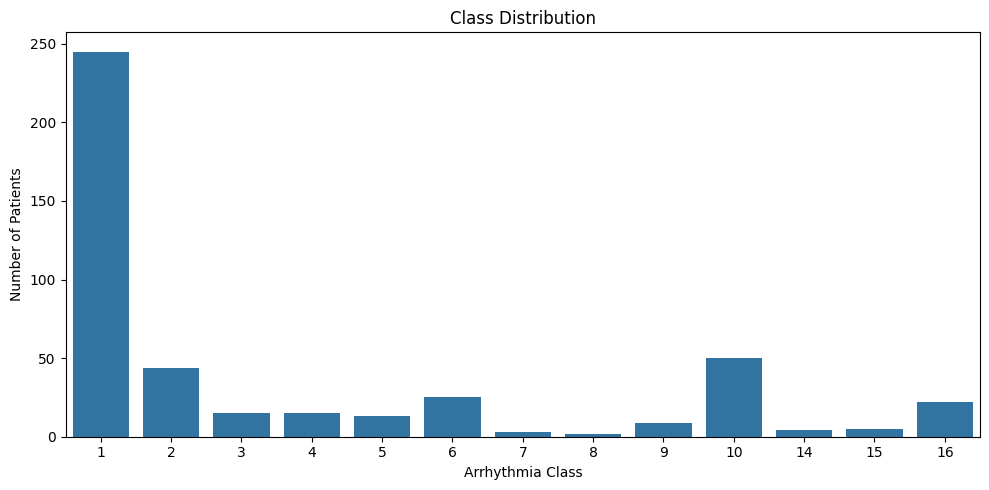

In [12]:
# Class Distribution

class_counts = y.value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=class_counts.index.astype(str),
    y=class_counts.values
)

plt.xlabel("Arrhythmia Class")
plt.ylabel("Number of Patients")
plt.title("Class Distribution")

plt.tight_layout()
plt.show()

In [13]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 361
Testing samples: 91


In [14]:
# Missing Value Imputation using median imputation

imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)

print(
    "Remaining missing values in training data:",
    X_train_imputed.isna().sum().sum()
)

print(
    "Remaining missing values in testing data:",
    X_test_imputed.isna().sum().sum()
)

Remaining missing values in training data: 0
Remaining missing values in testing data: 0


In [18]:
# Baseline CART Model

baseline_cart = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

baseline_cart.fit(X_train_imputed, y_train)

baseline_pred = baseline_cart.predict(X_test_imputed)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

baseline_precision = precision_score(
    y_test,
    baseline_pred,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    average="weighted",
    zero_division=0
)

print("Baseline CART Results")
print("---------------------")
print("Accuracy :", round(baseline_accuracy * 100, 2), "%")
print("Precision:", round(baseline_precision * 100, 2), "%")
print("Recall   :", round(baseline_recall * 100, 2), "%")
print("F1 Score :", round(baseline_f1 * 100, 2), "%")

Baseline CART Results
---------------------
Accuracy : 65.93 %
Precision: 68.22 %
Recall   : 65.93 %
F1 Score : 65.39 %


In [20]:
# CART Hyperparameter Tuning with Feature Selection

cart_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("selector", SelectKBest(score_func=f_classif)),
    ("cart", DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "selector__k": [30, 60, 100, "all"],
    "cart__criterion": ["gini","entropy"],
    "cart__max_depth": [5,7,10,None],
    "cart__min_samples_split": [2,5,10],
    "cart__min_samples_leaf": [1,2,5]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=cart_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train,y_train)

print("\nBEST PARAMETERS:")
print(grid_search.best_params_)

print(
    "\nBEST CV ACCURACY:",
    round(grid_search.best_score_ * 100, 2),
    "%"
)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


c:\Users\Nihira\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



BEST PARAMETERS:
{'cart__criterion': 'gini', 'cart__max_depth': 7, 'cart__min_samples_leaf': 5, 'cart__min_samples_split': 2, 'selector__k': 30}

BEST CV ACCURACY: 72.29 %


c:\Users\Nihira\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 18  46  66  68  71  82  84 102 130 131 138 140 142 143 144 150 155 156
 163 203 233 263 273] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Nihira\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [21]:
# Tuned CART Evaluation

best_cart = grid_search.best_estimator_

final_pred = best_cart.predict(X_test)

final_accuracy = accuracy_score(y_test,final_pred)

final_precision = precision_score(
    y_test,
    final_pred,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_pred,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_pred,
    average="weighted",
    zero_division=0
)

print("Tuned CART Results")
print("------------------")
print("Accuracy :", round(final_accuracy * 100, 2), "%")
print("Precision:", round(final_precision * 100, 2), "%")
print("Recall   :", round(final_recall * 100, 2), "%")
print("F1 Score :", round(final_f1 * 100, 2), "%")

Tuned CART Results
------------------
Accuracy : 72.53 %
Precision: 66.64 %
Recall   : 72.53 %
F1 Score : 68.64 %


In [22]:
# CART Tree Structure

cart_model = best_cart.named_steps["cart"]

print("Tree depth:", cart_model.get_depth())
print("Number of leaves:", cart_model.get_n_leaves())

Tree depth: 7
Number of leaves: 21


In [ ]:
# Feature Importance

cart_model = best_cart.named_steps["cart"]
selector = best_cart.named_steps["selector"]

selected_features = X_train.columns[
    selector.get_support()
]

feature_importance = pd.Series(
    cart_model.feature_importances_,
    index=selected_features
).sort_values(
    ascending=False
)

print("Number of selected features:", len(selected_features))

print("\nTop 20 Important Features:")
display(feature_importance.head(20))

Number of selected features: 30

Top 20 Important Features:


14     0.228816
196    0.187372
90     0.163719
111    0.096255
210    0.089271
92     0.053797
113    0.051469
237    0.034645
239    0.033975
247    0.015828
4      0.015707
6      0.011305
162    0.011042
229    0.004745
112    0.002054
136    0.000000
227    0.000000
250    0.000000
16     0.000000
240    0.000000
dtype: float64

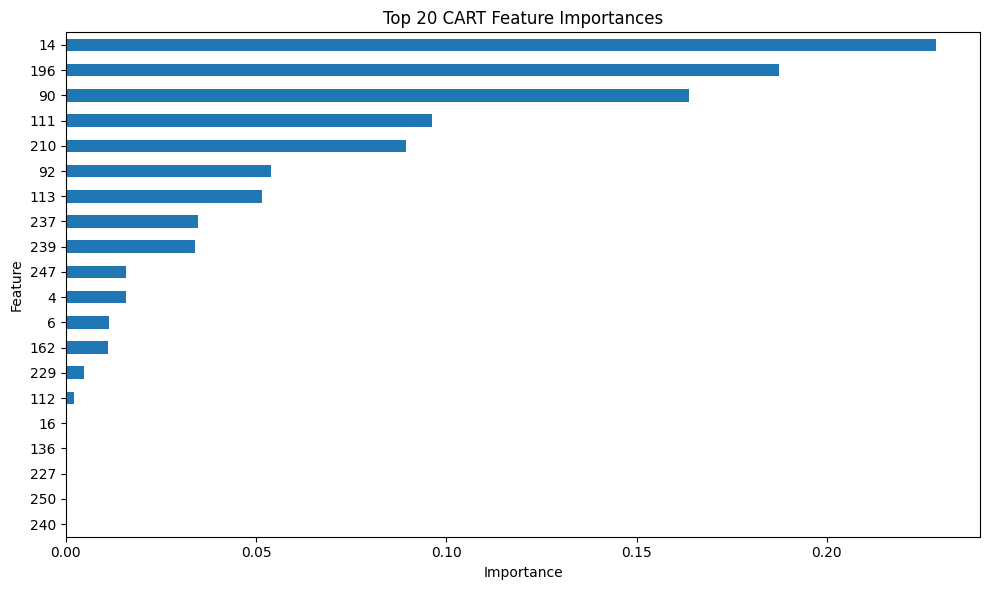

In [26]:
plt.figure(figsize=(10, 6))

feature_importance.head(20).sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 CART Feature Importances")

plt.tight_layout()
plt.show()

In [27]:
# Root Feature Analysis

root_index = cart_model.tree_.feature[0]

if root_index >= 0:
    root_feature = selected_features[root_index]
    print("Root Feature:", root_feature)
else:
    print("No root feature found.")

Root Feature: 90


In [28]:
# 70-30 Train-Test Split Evaluation

X_train70, X_test30, y_train70, y_test30 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

cart_7030 = GridSearchCV(
    cart_pipeline,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

cart_7030.fit(
    X_train70,
    y_train70
)

pred_7030 = cart_7030.predict(
    X_test30
)

accuracy_7030 = accuracy_score(
    y_test30,
    pred_7030
)

print(
    "70/30 CART Accuracy:",
    round(accuracy_7030 * 100, 2),
    "%"
)

c:\Users\Nihira\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


70/30 CART Accuracy: 67.65 %


c:\Users\Nihira\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\Nihira\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 18  20  46  66  68  71  82  84 102 130 131 138 140 142 143 144 150 155
 156 163 203 233 263 273] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Nihira\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [31]:
# 10-Fold Cross Validation

cv10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_cart,
    X,
    y,
    cv=cv10,
    scoring="accuracy",
    n_jobs=-1
)

print("10-Fold CV Scores:")
print(np.round(cv_scores * 100, 2))

print(
    "\nMean Accuracy:",
    round(cv_scores.mean() * 100, 2),
    "%"
)

print(
    "Standard Deviation:",
    round(cv_scores.std() * 100, 2),
    "%"
)

10-Fold CV Scores:
[67.39 69.57 68.89 68.89 73.33 64.44 68.89 77.78 60.   75.56]

Mean Accuracy: 69.47 %
Standard Deviation: 4.91 %


c:\Users\Nihira\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(


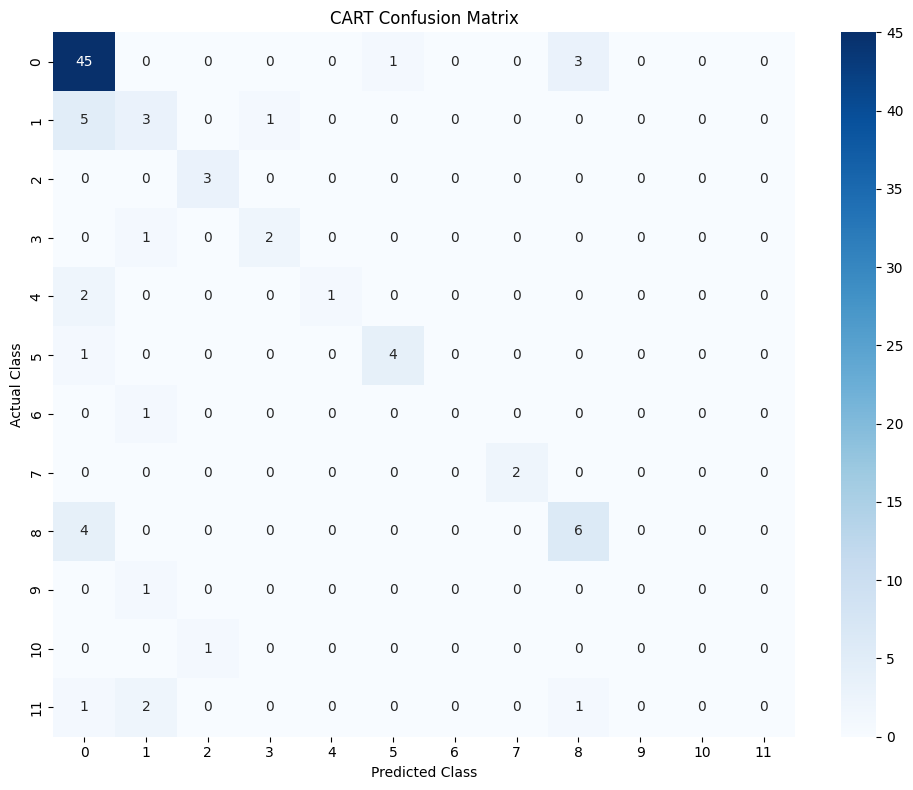

In [32]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CART Confusion Matrix")

plt.tight_layout()
plt.show()

In [33]:
# Classification Report

print(
    classification_report(
        y_test,
        final_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1       0.78      0.92      0.84        49
           2       0.38      0.33      0.35         9
           3       0.75      1.00      0.86         3
           4       0.67      0.67      0.67         3
           5       1.00      0.33      0.50         3
           6       0.80      0.80      0.80         5
           7       0.00      0.00      0.00         1
           9       1.00      1.00      1.00         2
          10       0.60      0.60      0.60        10
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         4

    accuracy                           0.73        91
   macro avg       0.50      0.47      0.47        91
weighted avg       0.67      0.73      0.69        91



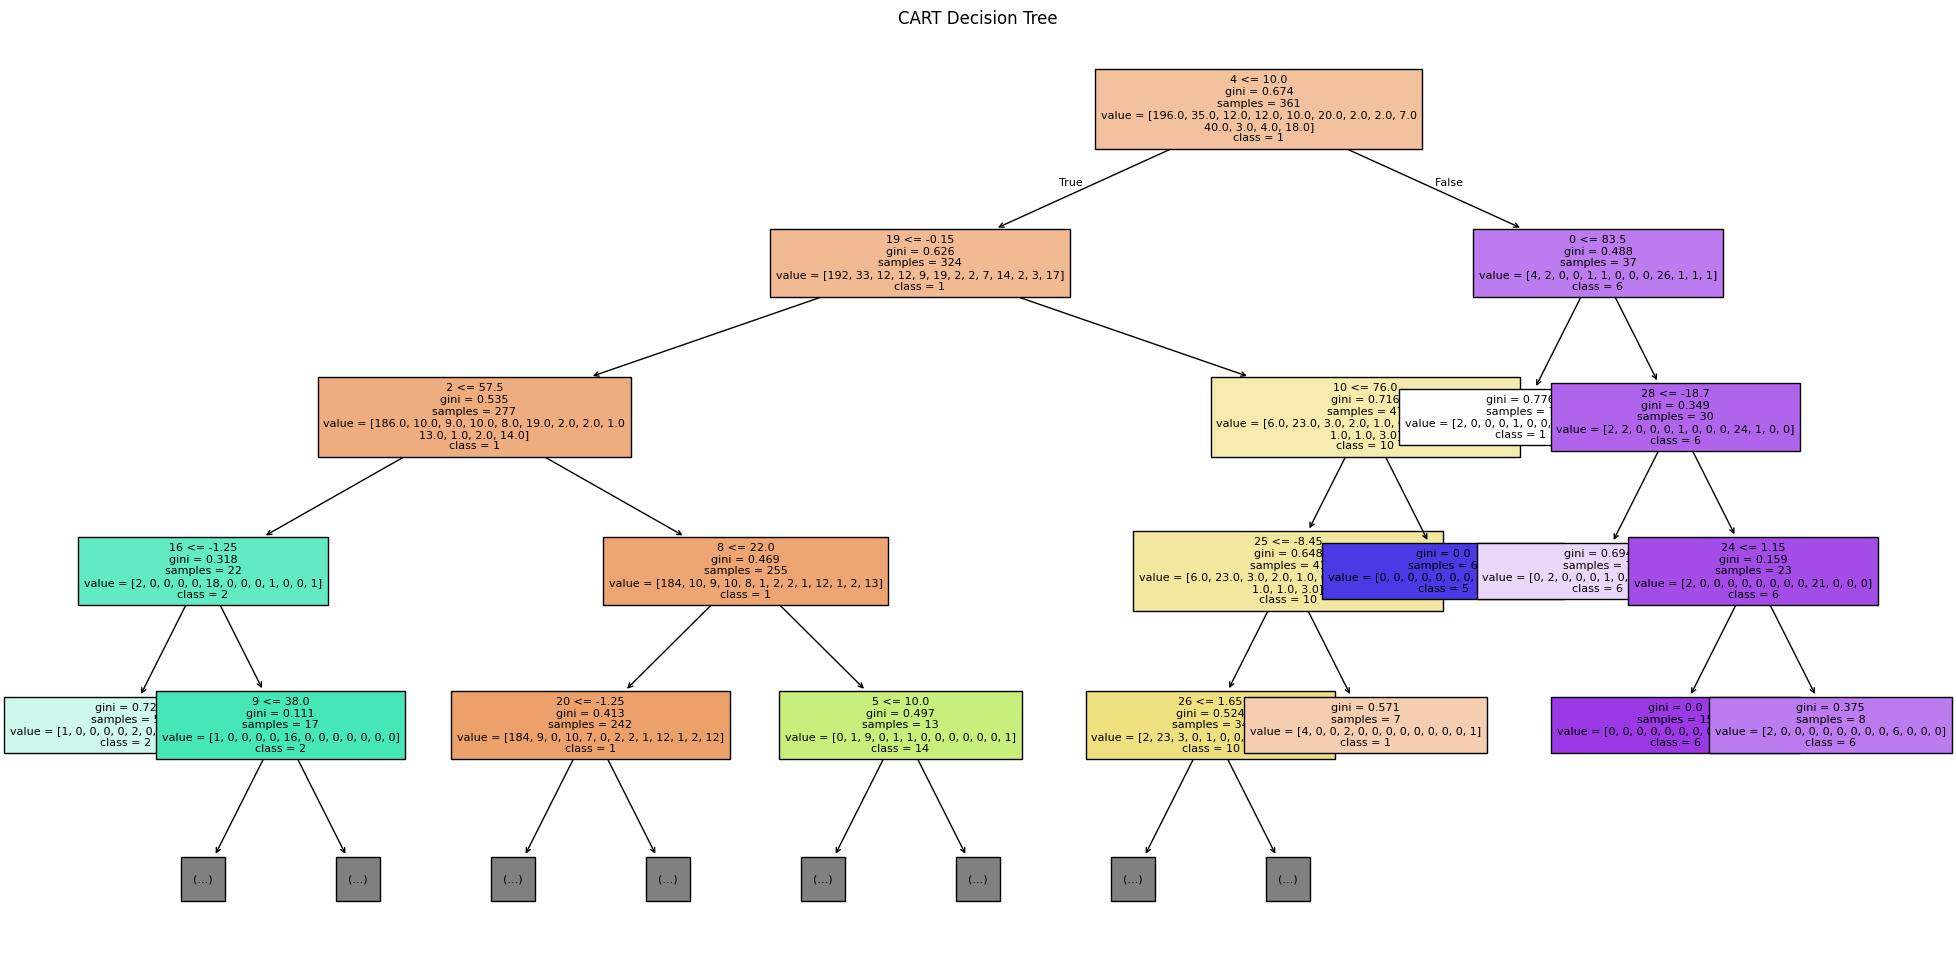

In [35]:
# CART Decision Tree Visualization

plt.figure(figsize=(24, 12))

plot_tree(
    cart_model,
    feature_names=X_train.columns.astype(str),
    class_names=sorted(y.astype(str).unique()),
    filled=True,
    max_depth=4,
    fontsize=8
)

plt.title("CART Decision Tree")
plt.show()

In [36]:
# Model Performance Summary

results = pd.DataFrame({
    "Experiment": [
        "Baseline CART",
        "Tuned CART",
        "70/30 CART",
        "10-Fold CV"
    ],

    "Accuracy (%)": [
        baseline_accuracy * 100,
        final_accuracy * 100,
        accuracy_7030 * 100,
        cv_scores.mean() * 100
    ]
})

display(results)

,Experiment,Accuracy (%)
0,Baseline CART,65.934066
1,Tuned CART,72.527473
2,70/30 CART,67.647059
3,10-Fold CV,69.473430


In [39]:
# Save Results

results.to_csv(
    "results/cart_results.csv",
    index=False
)

feature_importance.to_csv(
    "results/feature_importance.csv"
)

print("Results saved successfully.")

Results saved successfully.
